Remember we have 9 types of attacks:
- Fuzzers
- Analysis
- Backdoors
- DoS
- Exploits
- Generic
- REconnaissance
- Shellcode
- Worms

Each one of these have different indicative metrics that we need to be on the lookout for. If the goal is to minimize any of the above attacks (anomalous behavior) then we need to make sure that we flag any centroids / feature values that indicate these types of attacks.

### Clustering does not separate “good vs bad” — it separates “types of behavior.”

In this way we can interpret which patterns are normal and which are suspicious. The model is discovering different behavioral patterns, and then we can figure out which of these clustered behavioral patterns most strongly associated with attacks

# Let's compare attack-heavy clusters and normal-heavy clusters

In doing so, we will be able to see what behavioral differences explain the difference in %. A high % normal cluster represents typical traffic, while a high % non normal cluster captures attack-like behavior.

**For Each Cluster** we should ask...
    - Is it dominated by one category? (This would then be a strong, meaningful cluster)
    - Is it mixed (weaker less useful cluster)

Note that we also checked our findings with different n-clusters values (The number of clusters outputted by the mdoel). In doing so we were able to find the following...

- Attack clusters:
    - lower sbytes / dbytes
    - lower sload / dload
    - lower stcpb / dtcpb
    - higher rate
    - lower response_body_len
- Normal clusters:
    - higher bytes
    - higher load
    - higher response_body_len
    - lower rate

To explain these differences it's best to intuitively think about what we know about attack patterns within internet activity. They are often scripts, or repeated automations that are meant to run remotely. This explains the low jitter because the timing between actions is more uniform in a scripted environment than what we would expect human activity to look like. Attack-heavy clusters are characterized by high transmission rates and load, indicating bursty and intensive communication patterns. In contrast, normal clusters exhibit larger total data exchanges, higher response body lengths, and more variable timing behavior, suggesting sustained, application-driven interactions.

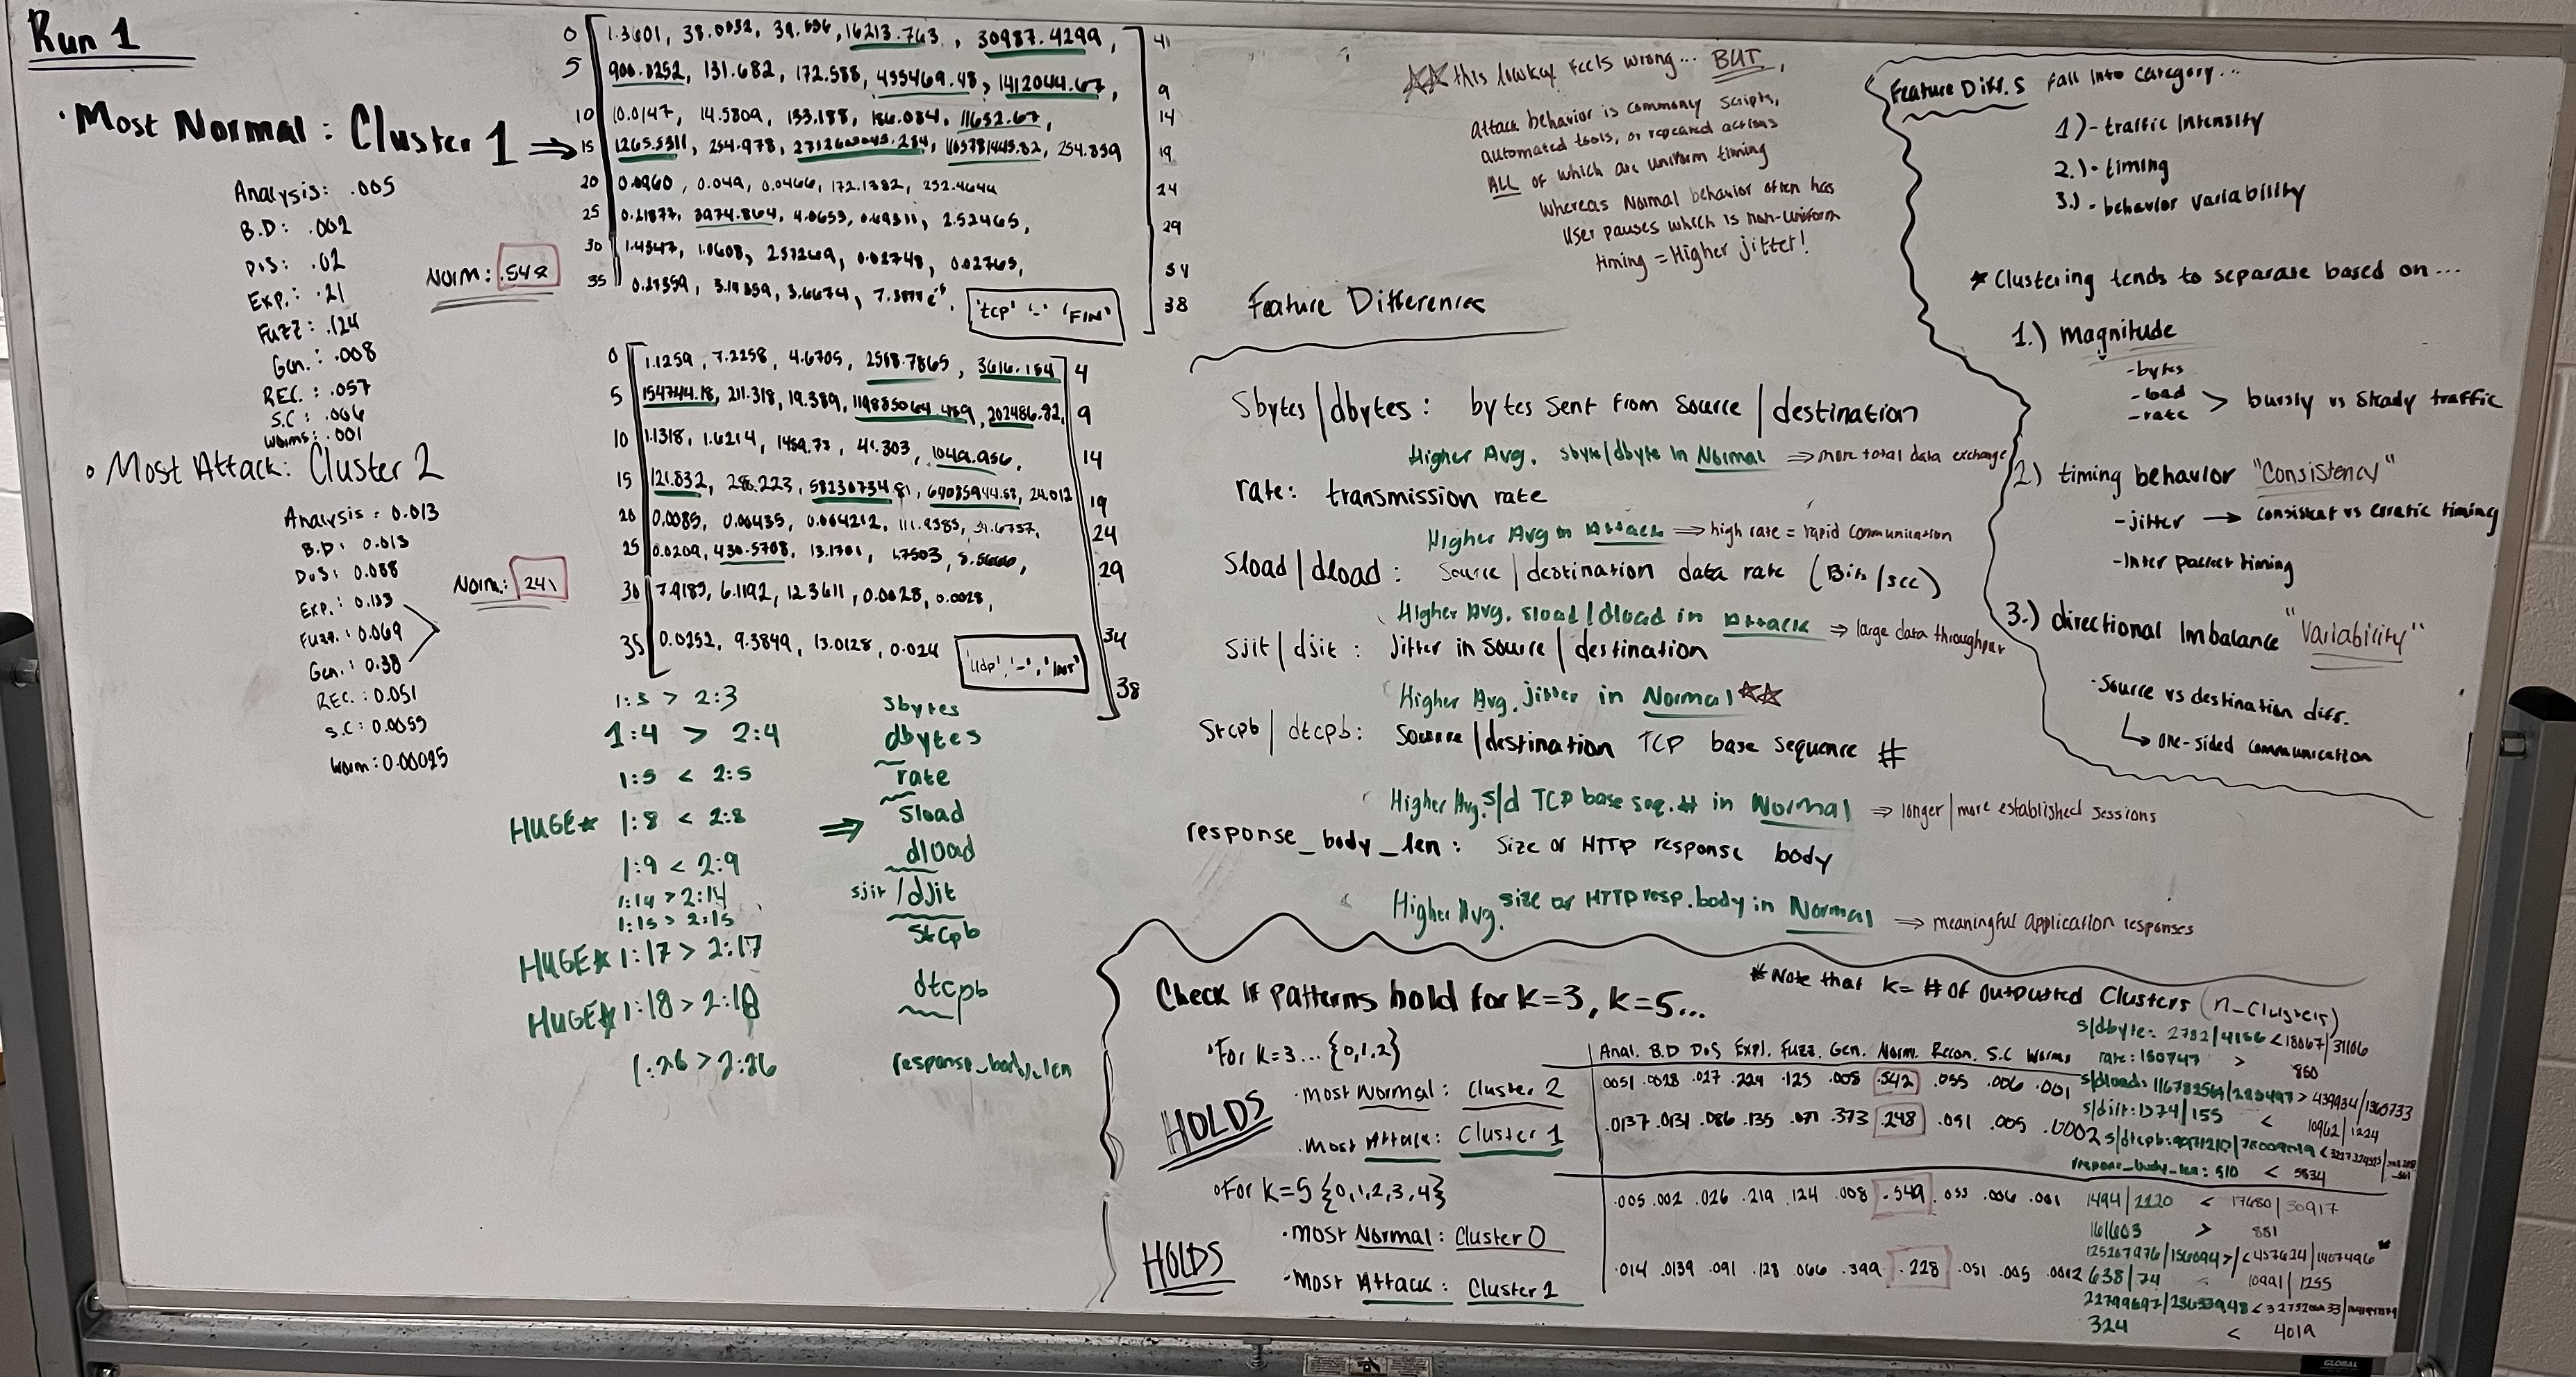

In [1]:
from IPython.display import Image, display
image_path = '../AI_Board.jpeg'
display(Image(filename=image_path))

# So now that we know what key things to look for, let's run our model with n_init = 5 and n_clusters = 4

But let's only output the categories that we know to be important. This will make it easier for us to draw comparisons!

In [2]:
# import numpy
# import kmodes
# from kmodes.kprototypes import KPrototypes

# #selects specific columns from our df_new and converts their data types to string
# df_new.iloc[:, [1,2,3]] = df_new.iloc[:, [1,2,3]].astype(str)
# #convert our df into numpy array
# data_np = df_new.to_numpy()

# #initialize our model using 4 clusters, using the Huang Variation, and n_init to 5 (which is how many times the algorithm will re run with different initial prototypes)
# km = KPrototypes(n_clusters=4, init='Huang', n_init=5, verbose=1)

# clusters = km.fit_predict(data_np, categorical=[1,2,3])

# # the following are to make our output clearer and more reaadable
# results_df = df_new.copy()
# results_df['cluster'] = clusters
# results_df['attack_cat'] = df_og['attack_cat']

# cluster_summary = (
#     results_df.groupby('cluster')['attack_cat']
#     .value_counts(normalize=True)
#     .unstack()
#     .fillna(0)
# )

# # % normal in each cluster
# normal_pct = cluster_summary['Normal']

# most_normal_cluster = normal_pct.idxmax() #this is the cluster that has the highest percentage of normal traffic, so we can assume that this cluster is mostly normal
# most_attack_cluster = normal_pct.idxmin() #this is the cluster that has the lowest percentage of normal traffic, so we can assume that this cluster is mostly attack traffic

# important_clusters = [most_normal_cluster, most_attack_cluster]

# centroids = km.cluster_centroids_

# selected_centroids = centroids[important_clusters]

# important_indices = [3,4,5,8,9,14,15,18,19,26]  # these are the feature values we determined to be important earlier
# filtered_centroids = selected_centroids[:, important_indices]


# print("Most Normal Cluster:", most_normal_cluster)
# print("Most Attack Cluster:", most_attack_cluster)

# print("\nFeature Comparison:")
# print(filtered_centroids)

# import pandas as pd #convert to data frame for better readability and visualization of the centroids of the most normal and most attack clusters, and to compare them side by side

# feature_names = [
#     'sbytes','dbytes','rate',
#     'sload','dload',
#     'sjit' , 'djit',
#     'stcpb','dtcpb',
#     'response_body_len'
# ]

# df_compare = pd.DataFrame(
#     filtered_centroids,
#     columns=feature_names,
#     index=['Most Normal', 'Most Attack']
# )

# print(cluster_summary.loc[important_clusters])
# print(df_compare)

# Results

From the above output we can see the following. 

| Cluster         | Normal | Exploits | Generic | Fuzzers | DoS    | Other |
| --------------- | ------ | -------- | ------- | ------- | ------ | ----- |
| Most Normal (2) | 0.5446 | 0.2233   | 0.0079  | 0.1262  | 0.0263 | small |
| Most Attack (3) | 0.2416 | 0.1328   | 0.3830  | 0.0694  | 0.0885 | small |


| Feature           | Most Normal | Most Attack |
| ----------------- | ----------- | ----------- |
| sbytes            | 15987       | 2479        |
| dbytes            | 30561       | 3633        |
| rate              | 862         | 154,809     |
| sload             | 435,470     | 119,935,511 |
| dload             | 1,408,489   | 203,383     |
| sjit              | 11,855      | 1,084       |
| djit              | 1,256       | 122         |
| stcpb             | 2.7e9       | 5.9e7       |
| dtcpb             | 254         | 23          |
| response_body_len | 4779        | 429         |


So we can conclude the following characteristics of Attack-Heavy clusters and Normal Clusters:

- Attack Heavy Clusters: Characterized by extremely high transmission rates and load, but low total data transfer and response sizes, indicating fast, lightweight, and repetitive communication patterns.
    
- Normal Clusters: Exhibits significantly higher data transfer, larger response sizes, and greater variability, consistent with richer, application-driven interactions.

Despite these differences, clusters are not pure, with attack-heavy clusters still containing ~24% normal traffic, highlighting overlap between normal and malicious behavior

# Comparison

The alternative option to a k-prototypes model is a k-means model. K-Means offers significant advantages over K-Prototypes primarily through higher computational speed, simpler implementation, and better stability, making it superior for large-scale, purely numerical datasets. K-Means is widely supported, efficient for high-dimensional data, and guarantees convergence, whereas K-Prototypes is complex to tune and slower due to processing mixed numerical/categorical data

But we had categorical data, so we went with k-prototype for our clustering model. Let's compare the results from our model to an off the shelf k-means model! *Note that we will have to use one-hot-encoding to ensure that our categorical values can be handled by the k-means model.

In [3]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# import pandas as pd
# from sklearn.preprocessing import OneHotEncoder

# categorical_cols = ['proto', 'service', 'state']
# encoder = OneHotEncoder(sparse_output=False)
# encoded = encoder.fit_transform(df_new[categorical_cols])
# encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# # Drop original categorical columns and concatenate encoded columns
# df_kmeans = pd.concat([df_new.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)

In [5]:
# from sklearn.cluster import KMeans

# kmeans = KMeans(n_clusters=4, random_state=42)
# clusters = kmeans.fit_predict(df_kmeans)

# print("KMeans Cluster Centers:")
# print(kmeans.cluster_centers_)

In [6]:
# # Create a DataFrame with KMeans cluster assignments and attack labels
# means_results_df = pd.DataFrame({
#     'cluster': clusters,
#     'attack_cat': labels.reset_index(drop=True)
# })

# # Crosstab: percentage of each attack category in each cluster
# kmeans_crosstab = pd.crosstab(
#     means_results_df['cluster'],
#     means_results_df['attack_cat'],
#     normalize='index'
# )

# print(kmeans_crosstab)

While k-means produced clusters with similar distributions of attack and normal traffic, the interpretability of these clusters was significantly reduced. This is due to the need to encode categorical features numerically, which results in centroids containing fractional values that do not correspond to real network states or protocols.

In contrast, k-prototypes preserves categorical features directly, allowing clusters to be interpreted in terms of actual network behavior (e.g., UDP–INT connections). This makes k-prototypes more suitable for intrusion detection, where understanding the nature of traffic is critical.